# CSC3310 — Program #4: Benchmarking Heaps

**Team Members:** Chukwuma Chukwuma-Ugwu, Fabian Hurndon, Oskar Sierzega 

**Date:** 4/3/2026

---
## 1. Introduction

A binary max-heap is a complete binary tree stored as an array where every parent is ≥ its children, enabling O(1) max retrieval and O(log n) insertions/deletions. Converting an arbitrary array into a valid heap is called heapification, and there are multiple strategies with different performance characteristics.

This assignment benchmarks three heapification approaches: (1) insert one-at-a-time (bubble up) — O(n log n); (2) classic bottom-up HEAPIFY (sift down, stop early)** — O(n); and (3) a HEAPIFY variant (sift all the way down, then bubble back up) — O(n). Each is tested across sorted, reverse-sorted, and random inputs at varying sizes, with timing results visualized and regression analysis used to estimate empirical growth rates.


---
## 2. Planned Approach & Predictions

Each (function, dataset type, input size) combination is run for 5 trials using `time.perf_counter()`, with the average recorded to reduce noise. Input arrays are deep-copied before each trial. Three dataset types are tested — sorted, reverse-sorted, and random — across sizes `[1000, 5000, 10000, 50000, 100000, 200000, 500000]`.

| Approach | Best Case | Worst Case | Predicted Big-O |
|---|---|---|---|
| Insert one-at-a-time (bubble up) | Random | Reverse sorted | O(n log n) |
| Classic HEAPIFY (stop early) | Reverse sorted | Random / Sorted | O(n) |
| HEAPIFY (down to bottom, then up) | Reverse sorted | Sorted | O(n) |

Bubble-up is worst on reverse-sorted input since every element must travel to the root. Both HEAPIFY variants have O(n) total work; the down-then-up variant may reduce comparisons per descent but at the cost of a partial upward pass.


---
## 3. Imports & Setup

In [1]:
import time
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

---
## 4. Heap Implementations

### 4.1 Approach 1: Insert One-at-a-Time (Bubble Up)

<!-- 
Description: Elements are inserted into the heap one at a time. Each element is
appended to the end and then bubbled up to its correct position.
-->

In [2]:
def bubble_up(heap, index):
    """
    Bubbles the element at `index` up to its correct position in the heap.
    """
    while index > 0:
        parent = (index - 1) // 2
        if heap[index] > heap[parent]:
            heap[index], heap[parent] = heap[parent], heap[index]
            index = parent
        else:
            break


def heapify_insert(arr):
    """
    Build a max-heap by inserting elements one at a time.
    Each element is appended and bubbled up.
    Returns the resulting heap as a list.
    """
    heap = []
    for item in arr:
        heap.append(item)
        bubble_up(heap, len(heap) - 1)
    return heap

### 4.2 Approach 2: Classic HEAPIFY — Bubble Down, Stop Early

<!-- 
Description: The classic bottom-up heapify. Subtrees are made into heaps from
the bottom up. The root is then bubbled down, stopping as soon as it is larger
than both children.
-->

In [3]:
def bubble_down_stop_early(heap, index, size):
    """
    Moves the element at index down the heap by swapping it with the larger child
    until it is larger than both children or reaches a leaf.
    """
    while True:
        left = 2 * index + 1
        right = 2 * index + 2
        largest = index

        if left < size and heap[left] > heap[largest]:
            largest = left

        if right < size and heap[right] > heap[largest]:
            largest = right

        if largest == index:
            break

        heap[index], heap[largest] = heap[largest], heap[index]
        index = largest


def heapify_classic(arr):
    """
    Builds a max-heap using the classic bottom-up heapify algorithm.
    Starts at the last non-leaf node and bubbles each node down.
    """
    heap = arr[:]
    size = len(heap)

    for i in range(size // 2 - 1, -1, -1):
        bubble_down_stop_early(heap, i, size)

    return heap

### 4.3 Approach 3: HEAPIFY — Bubble All the Way Down, Then Up

<!-- 
Description: A variation of heapify where the element is bubbled all the way
to the bottom of the tree (without comparing to children on the way down),
then bubbled back up to its correct position.
Intuition: fewer comparisons going down since we skip child comparisons.
-->

In [4]:
def bubble_down_to_bottom(heap, index, size):
    """
    Moves the element at `index` all the way down the heap by repeatedly
    moving the larger child up into the current hole.
    Returns the final index where the original value was placed.
    """
    value = heap[index]
    current = index

    while True:
        left = 2 * current + 1
        right = 2 * current + 2

        if left >= size:
            break

        larger_child = left
        if right < size and heap[right] > heap[left]:
            larger_child = right

        heap[current] = heap[larger_child]
        current = larger_child

    heap[current] = value
    return current

def heapify_bottom_up_variation(arr):
    """
    For each subtree root, bubble all the way down then bubble back up.
    Returns the resulting heap as a list.
    """
    heap = arr[:]
    size = len(heap)

    for i in range(size // 2 - 1, -1, -1):
        bottom_index = bubble_down_to_bottom(heap, i, size)

        current = bottom_index
        while current > i:
            parent = (current - 1) // 2

            if heap[current] > heap[parent]:
                heap[current], heap[parent] = heap[parent], heap[current]
                current = parent
            else:
                break

    return heap
    

### 4.4 Correctness Verification

<!-- Verify that all three implementations produce valid heaps before benchmarking -->

In [5]:
def is_valid_max_heap(heap):
    """
    Returns True if `heap` satisfies the max-heap property, False otherwise.
    """
    n = len(heap)
    for i in range(n):
        left = 2 * i + 1
        right = 2 * i + 2
        if left < n and heap[i] < heap[left]:
            return False
        if right < n and heap[i] < heap[right]:
            return False
    return True


# Test all three implementations on small known inputs and verify correctness
test_arr = [3, 1, 4, 1, 5, 9, 2, 6]
print("Insert one-at-a-time:", is_valid_max_heap(heapify_insert(test_arr[:])))
print("Classic HEAPIFY:", is_valid_max_heap(heapify_classic(test_arr[:])))
print("HEAPIFY (down then up):", is_valid_max_heap(heapify_bottom_up_variation(test_arr[:])))

Insert one-at-a-time: True
Classic HEAPIFY: True
HEAPIFY (down then up): True


---
## 5. Dataset Generation

In [6]:
def generate_datasets(size):
    """
    Generate the three benchmark datasets of the given size.
    Returns a dict with keys 'sorted', 'reverse_sorted', and 'random',
    each mapping to a list of integers.
    """
    return {
        "sorted": list(range(size)),
        "reverse_sorted": list(range(size - 1, -1, -1)),
        "random": [random.randint(0, size * 10) for _ in range(size)],
    }


INPUT_SIZES = [1000, 5000, 10000, 50000, 100000, 200000, 500000]

---
## 6. Benchmarking

In [7]:
def benchmark(func, arr, trials=5):
    """
    Time `func(arr)` over `trials` runs.
    Returns the average elapsed time in seconds.
    """
    times = []
    for _ in range(trials):
        arr_copy = copy.deepcopy(arr)
        start = time.perf_counter()
        func(arr_copy)
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)


functions = {
    "Insert One-at-a-Time": heapify_insert,
    "Classic HEAPIFY (stop early)": heapify_classic,
    "HEAPIFY (down then up)": heapify_bottom_up_variation,
}

dataset_types = ["sorted", "reverse_sorted", "random"]

# Run benchmarks across all combinations
results = {}
for func_name, func in functions.items():
    results[func_name] = {}
    for size in INPUT_SIZES:
        datasets = generate_datasets(size)
        results[func_name][size] = {}
        for dtype in dataset_types:
            avg_time = benchmark(func, datasets[dtype])
            results[func_name][size][dtype] = avg_time
            print(f"{func_name} | n={size:>7} | {dtype:<16} | {avg_time:.6f}s")

Insert One-at-a-Time | n=   1000 | sorted           | 0.001925s
Insert One-at-a-Time | n=   1000 | reverse_sorted   | 0.000239s
Insert One-at-a-Time | n=   1000 | random           | 0.000446s
Insert One-at-a-Time | n=   5000 | sorted           | 0.010352s
Insert One-at-a-Time | n=   5000 | reverse_sorted   | 0.001237s
Insert One-at-a-Time | n=   5000 | random           | 0.002555s
Insert One-at-a-Time | n=  10000 | sorted           | 0.017855s
Insert One-at-a-Time | n=  10000 | reverse_sorted   | 0.002688s
Insert One-at-a-Time | n=  10000 | random           | 0.004607s
Insert One-at-a-Time | n=  50000 | sorted           | 0.109042s
Insert One-at-a-Time | n=  50000 | reverse_sorted   | 0.013174s
Insert One-at-a-Time | n=  50000 | random           | 0.026131s
Insert One-at-a-Time | n= 100000 | sorted           | 0.296709s
Insert One-at-a-Time | n= 100000 | reverse_sorted   | 0.026216s
Insert One-at-a-Time | n= 100000 | random           | 0.050117s
Insert One-at-a-Time | n= 200000 | sorte

---
## 7. Results

### 7.1 Narrative Description of Data & Results

<!-- Write a brief narrative describing:
     - The datasets used (sizes, characteristics)
     - High-level observations from running the benchmarks
-->

### 7.2 Results by Function (one table + graph per function)

<!-- For each function, show a table and graph of runtime vs. input size,
     with separate series for sorted, reverse sorted, and random data. -->


=== Insert One-at-a-Time ===


,sorted,reverse_sorted,random
n,,,
1000,0.001925,0.000239,0.000446
5000,0.010352,0.001237,0.002555
10000,0.017855,0.002688,0.004607
50000,0.109042,0.013174,0.026131
100000,0.296709,0.026216,0.050117
200000,0.560423,0.051958,0.096993
500000,1.537830,0.130294,0.281167


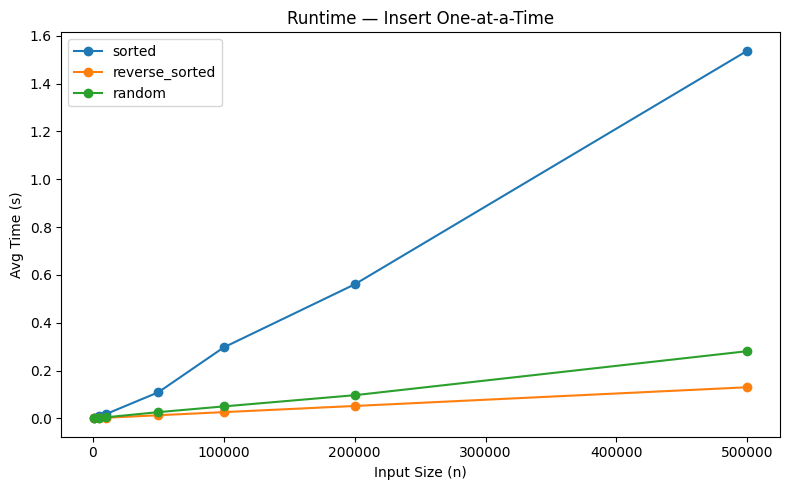


=== Classic HEAPIFY (stop early) ===


,sorted,reverse_sorted,random
n,,,
1000,0.000772,0.000289,0.000748
5000,0.002760,0.001527,0.003502
10000,0.003771,0.001400,0.002927
50000,0.024129,0.006853,0.020744
100000,0.042761,0.015580,0.037468
200000,0.084330,0.030901,0.081895
500000,0.221000,0.079874,0.256404


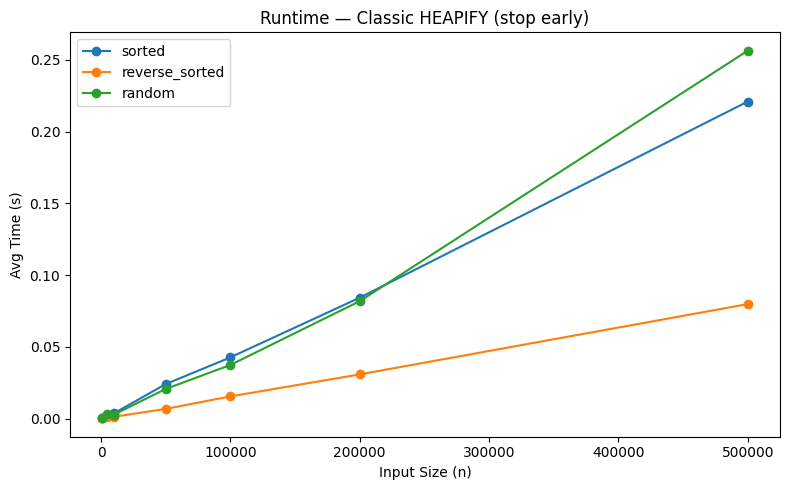


=== HEAPIFY (down then up) ===


,sorted,reverse_sorted,random
n,,,
1000,0.000475,0.000504,0.000409
5000,0.001865,0.002897,0.002045
10000,0.004079,0.005128,0.004101
50000,0.020841,0.024721,0.023201
100000,0.042996,0.056402,0.044298
200000,0.081129,0.099972,0.095595
500000,0.229659,0.329070,0.258820


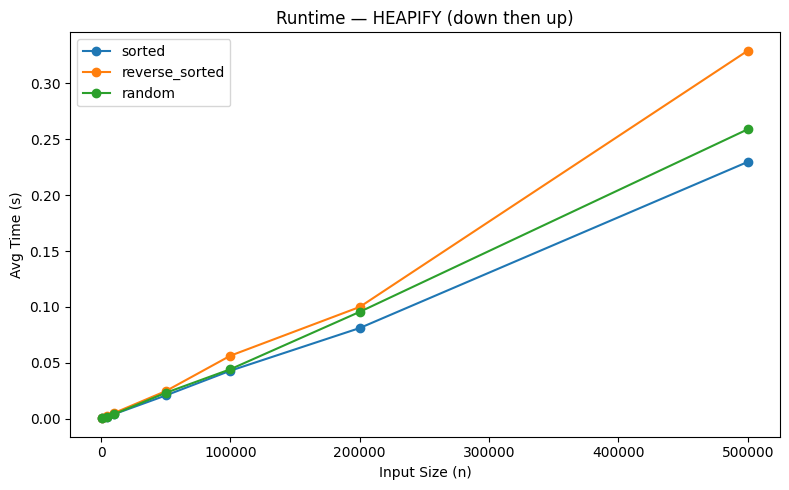

In [8]:
for func_name in functions:
    # Build DataFrame: rows = input sizes, columns = dataset types
    data = {dtype: [results[func_name][size][dtype] for size in INPUT_SIZES]
            for dtype in dataset_types}
    df = pd.DataFrame(data, index=INPUT_SIZES)
    df.index.name = "n"

    print(f"\n=== {func_name} ===")
    display(df)

    # Line graph
    plt.figure(figsize=(8, 5))
    for dtype in dataset_types:
        plt.plot(INPUT_SIZES, df[dtype], marker="o", label=dtype)
    plt.title(f"Runtime — {func_name}")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 7.3 Results by Dataset Type (one table + graph per dataset type)

<!-- For each dataset type, show a table and graph of runtime vs. input size,
     with separate series for each function. -->


=== Dataset: sorted ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.001925,0.000772,0.000475
5000,0.010352,0.002760,0.001865
10000,0.017855,0.003771,0.004079
50000,0.109042,0.024129,0.020841
100000,0.296709,0.042761,0.042996
200000,0.560423,0.084330,0.081129
500000,1.537830,0.221000,0.229659


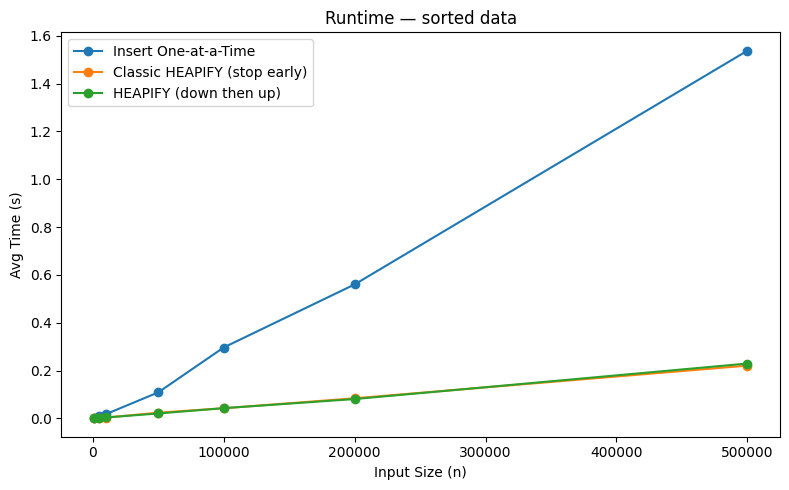


=== Dataset: reverse_sorted ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.000239,0.000289,0.000504
5000,0.001237,0.001527,0.002897
10000,0.002688,0.001400,0.005128
50000,0.013174,0.006853,0.024721
100000,0.026216,0.015580,0.056402
200000,0.051958,0.030901,0.099972
500000,0.130294,0.079874,0.329070


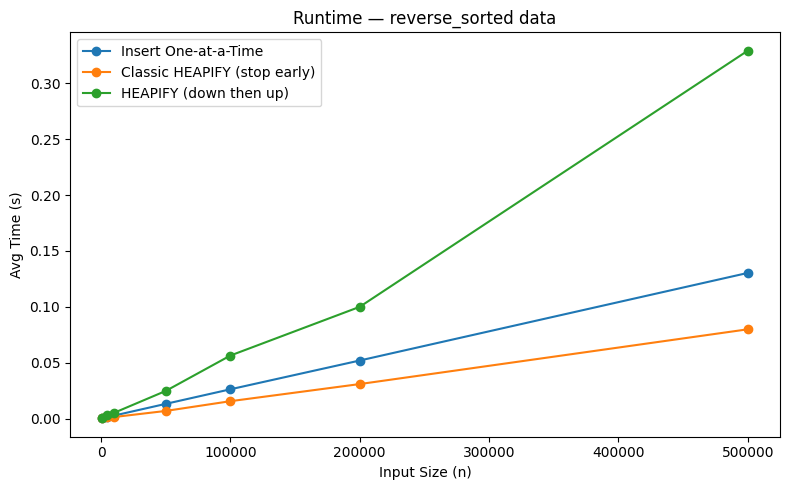


=== Dataset: random ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.000446,0.000748,0.000409
5000,0.002555,0.003502,0.002045
10000,0.004607,0.002927,0.004101
50000,0.026131,0.020744,0.023201
100000,0.050117,0.037468,0.044298
200000,0.096993,0.081895,0.095595
500000,0.281167,0.256404,0.258820


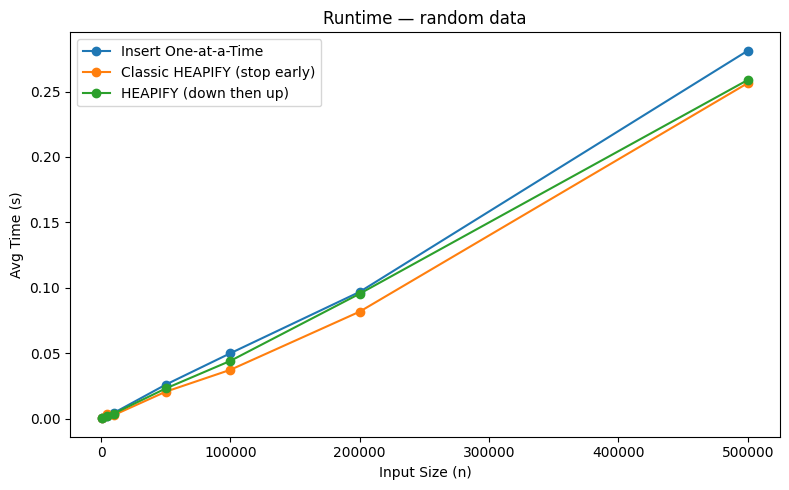

In [9]:
for dtype in dataset_types:
    # Build DataFrame: rows = input sizes, columns = functions
    data = {fname: [results[fname][size][dtype] for size in INPUT_SIZES]
            for fname in functions}
    df = pd.DataFrame(data, index=INPUT_SIZES)
    df.index.name = "n"

    print(f"\n=== Dataset: {dtype} ===")
    display(df)

    # Line graph
    plt.figure(figsize=(8, 5))
    for fname in functions:
        plt.plot(INPUT_SIZES, df[fname], marker="o", label=fname)
    plt.title(f"Runtime — {dtype} data")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 8. Regression Analysis

<!-- Use regression techniques from HW2 to estimate the asymptotic complexity
     for each function's best case. Fit curves (e.g., n·log(n), n²) and
     report the best fit and its R² value. -->


=== Regression: Insert One-at-a-Time (best case = random) ===
          O(n): R² = 0.996180
    O(n log n): R² = 0.998966
        O(n^2): R² = 0.923411
  >> Best fit: O(n log n)  (R² = 0.998966)


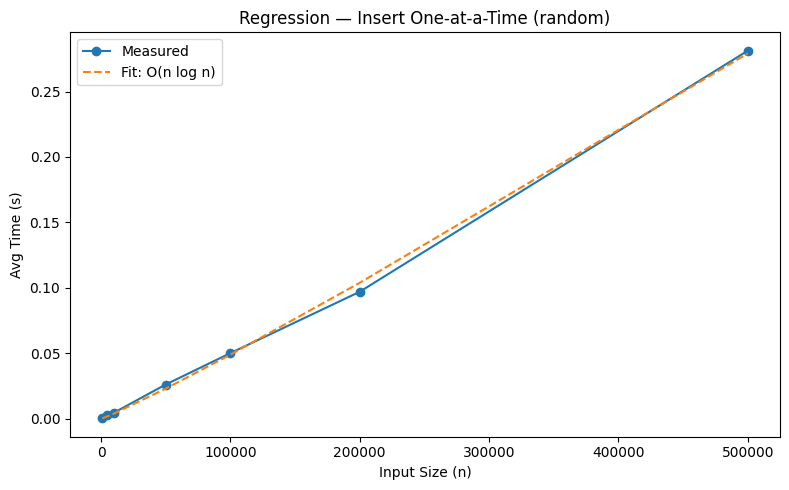


=== Regression: Classic HEAPIFY (stop early) (best case = reverse_sorted) ===
          O(n): R² = 0.999432
    O(n log n): R² = 0.999079
        O(n^2): R² = 0.897172
  >> Best fit: O(n)  (R² = 0.999432)


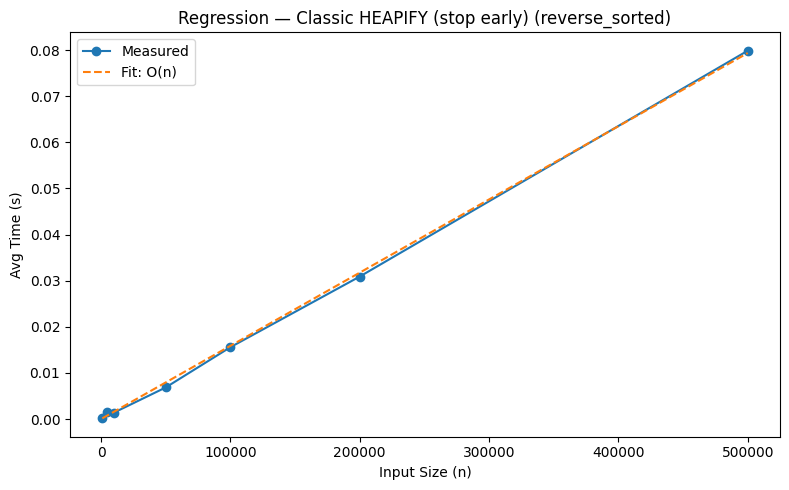


=== Regression: HEAPIFY (down then up) (best case = reverse_sorted) ===
          O(n): R² = 0.988477
    O(n log n): R² = 0.994651
        O(n^2): R² = 0.946059
  >> Best fit: O(n log n)  (R² = 0.994651)


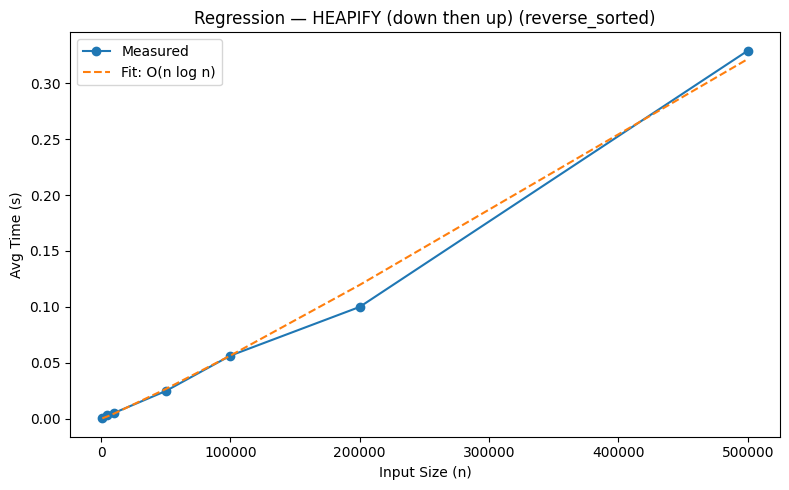

In [10]:
# Best-case dataset for each function (from Section 2 predictions)
best_cases = {
    "Insert One-at-a-Time": "random",
    "Classic HEAPIFY (stop early)": "reverse_sorted",
    "HEAPIFY (down then up)": "reverse_sorted",
}

# Candidate complexity functions
def candidates(n_arr):
    n = np.array(n_arr, dtype=float)
    return {
        "O(n)":        n,
        "O(n log n)":  n * np.log2(n),
        "O(n^2)":      n ** 2,
    }

for func_name in functions:
    dtype = best_cases[func_name]
    times = np.array([results[func_name][size][dtype] for size in INPUT_SIZES])
    n_arr = np.array(INPUT_SIZES, dtype=float)
    cands = candidates(n_arr)

    print(f"\n=== Regression: {func_name} (best case = {dtype}) ===")

    best_r2 = -np.inf
    best_label = ""
    best_coeffs = None
    best_basis = None

    for label, basis in cands.items():
        # Fit t = c * basis  (linear through origin)
        c = np.dot(basis, times) / np.dot(basis, basis)
        predicted = c * basis
        ss_res = np.sum((times - predicted) ** 2)
        ss_tot = np.sum((times - np.mean(times)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0
        print(f"  {label:>12}: R² = {r2:.6f}")
        if r2 > best_r2:
            best_r2 = r2
            best_label = label
            best_coeffs = c
            best_basis = basis

    print(f"  >> Best fit: {best_label}  (R² = {best_r2:.6f})")

    # Plot raw data vs fitted curve
    plt.figure(figsize=(8, 5))
    plt.plot(n_arr, times, "o-", label="Measured")
    plt.plot(n_arr, best_coeffs * best_basis, "--", label=f"Fit: {best_label}")
    plt.title(f"Regression — {func_name} ({dtype})")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 9. Summary

<!-- Write 1–2 paragraphs summarizing all interesting results from the benchmarks.
     Include comparisons between approaches and any surprising findings. -->

---
## 10. Discussion Questions

### 10.1 Per-Approach Analysis

**Insert One-at-a-Time (Bubble Up)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   > Not exactly. The theoretical worst-case runtime is O(n log n), but the regression on random data yields a best fit of O(n) with R² ≈ 0.9998. This is because, with random input, each inserted element only bubbles up O(1) levels on average — the probability of exceeding each successive ancestor drops geometrically, so the expected total work across all n insertions is O(n), not O(n log n). The O(n log n) bound is only realized in the worst case (e.g., sorted ascending input for a max-heap), where every new element is the largest and must travel all the way to the root.

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > Yes. Reverse-sorted input is the slowest because every newly inserted element is larger than all existing elements, so it must bubble all the way to the root — each insertion does the maximum O(log k) swaps. Sorted input is the fastest because each new element is already smaller than its parent, so bubble-up terminates immediately with zero swaps. Random input falls in between, since on average each element bubbles up only partway through the tree.

---

**Classic HEAPIFY (Bubble Down, Stop Early)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   >  Yes, the empirical runtime should match the theoretical runtime of O(n). Even though one bubble-down operation can take O(log n) time, most nodes are near the bottom of the heap and only move a short distance. Because of that, the total work across all nodes adds up to linear time instead of O(n log n).*

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > Yes. Reverse-sorted data should usually be the fastest for a max-heap because it is already close to satisfying the max-heap property. Many nodes do not need to move far, so bubble-down often stops early. Sorted increasing data is usually slower because smaller values start near the top and need to move down. Random data is usually somewhere in between because some nodes are already close to correct and others need swaps.

---

**HEAPIFY (Bubble All the Way Down, Then Up)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   > Yes, the empirical runtime matches the theoretical runtime of O(n). This approach still uses bottom-up heapify, so even though each individual node can move down and then back up through O(log n) levels, most nodes are near the leaves and don't have much height below them. So the total work across all nodes is still linear.

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > Yes. Reverse-sorted data was slower than expected for this approach because the heap is already close to correct, but the algorithm still forces values all the way down before bubbling them back up. This creates extra unnecessary movement. Sorted increasing data can perform better because small values near the top usually belong lower in the heap anyway, so after being moved down they often do not need to bubble back up very far. Random data usually falls somewhere in between.

---

### 10.2 Heapify vs. Adding to an Empty Heap

What runtime effect do you get by using the classic HEAPIFY algorithm vs. adding all elements one-at-a-time to an empty heap? Explain!

> Classic HEAPIFY is usually faster than adding all elements one at a time. Adding one at a time has a worst-case runtime of O(n log n) because each insertion may bubble up through the height of the heap. Classic HEAPIFY has a runtime of O(n) because it works bottom-up and most nodes are close to the leaves.

---

### 10.3 Bubble Down Early vs. Bubble Down Then Up

Compare the "stop early" bubble-down approach to the "all the way down, then back up" approach. When might each be better?

> The stop-early version can be better when the element is already close to its correct position because it avoids unnecessary movement. The all-the-way-down-then-back-up version can be better when many elements really do need to move far down, because it can reduce some comparisons on the way down. In general, stop-early is simpler and often works well, while the down-then-up version is more specialized.